In [20]:
import sys, sklearn, pandas as _pd
print("python :", sys.version.split()[0])
print("sklearn:", sklearn.__version__)
print("pandas :", _pd.__version__)
IN_COLAB = 'google.colab' in sys.modules
print("Colab  :", IN_COLAB)


python : 3.12.13
sklearn: 1.6.1
pandas : 2.2.2
Colab  : True


In [21]:
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             f1_score, precision_score, recall_score)

RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


In [22]:
URL_EN = "https://raw.githubusercontent.com/Satwato/Kaggle-NLP-with-Disaster-Tweets/master/train.csv"
try:
    df = pd.read_csv("disaster_tweets.csv")      # local copy, if your instructor gave you one
except FileNotFoundError:
    df = pd.read_csv(URL_EN)

print(f"Loaded {len(df)} tweets — columns: {list(df.columns)}")
df.head(3)

Loaded 7613 tweets — columns: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


In [23]:
#class balance
print(df['target'].value_counts())
print()
print(df['target'].value_counts(normalize=True))

target
0    4342
1    3271
Name: count, dtype: int64

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [24]:
#missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Count': missing_count, 'Percentage': missing_percent})
print(missing_df)

          Count  Percentage
id            0    0.000000
keyword      61    0.801261
location   2533   33.272035
text          0    0.000000
target        0    0.000000


In [25]:
df['keyword'] = df['keyword'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')

print(df.isnull().sum())

id          0
keyword     0
location    0
text        0
target      0
dtype: int64


In [26]:
#Read twenty real tweets
disaster_tweets = df[df['target'] == 1]['text'].sample(10, random_state=RANDOM_STATE).tolist()
non_disaster_tweets = df[df['target'] == 0]['text'].sample(10, random_state=RANDOM_STATE).tolist()

print("--- DISASTER TWEETS ---")
for i, tweet in enumerate(disaster_tweets, 1):
    print(f"{i}. {tweet}")

print("\n--- NON-DISASTER TWEETS ---")
for i, tweet in enumerate(non_disaster_tweets, 1):
    print(f"{i}. {tweet}")

--- DISASTER TWEETS ---
1. Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa
2. Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C
3. @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.
4. Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)
5. LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER
6. ÛÏA voluntary evacuation is being recommended at this timeÛ for Pickerel Lake cabins across highway from #Reidlake fire says MACA #NWT #YZF
7. Gold Coast tram hit by fallen powerlines: UP to 30 people have been evacuated from a tram on the Gold Coast af... http://t.co/xpPQnYHiWC
8. nbanews Soudelor Typhoon Soudelor is taking dead aim at Taiwan and is expected to make landfall Friday according to the Joint TyphoonÛ_
9. We will be burning up like neon lights??????
10. Ain't no hoe in my

In [27]:
#Noise inventory
has_urls = df['text'].str.contains(r'http\S+', regex=True).sum()
has_mentions = df['text'].str.contains(r'@\w+', regex=True).sum()
has_hashtags = df['text'].str.contains(r'#\w+', regex=True).sum()
has_negations = df['text'].str.contains(r'\b(not|no|never)\b', case=False, regex=True).sum()

print(f"Tweets with URLs: {has_urls} ({has_urls/len(df)*100:.1f}%)")
print(f"Tweets with Mentions: {has_mentions} ({has_mentions/len(df)*100:.1f}%)")
print(f"Tweets with Hashtags: {has_hashtags} ({has_hashtags/len(df)*100:.1f}%)")
print(f"Tweets with Negations: {has_negations} ({has_negations/len(df)*100:.1f}%)")

Tweets with URLs: 3971 (52.2%)
Tweets with Mentions: 2009 (26.4%)
Tweets with Hashtags: 1743 (22.9%)
Tweets with Negations: 584 (7.7%)


         count       mean       std  min   25%   50%   75%   max
target                                                          
0       4342.0  14.704744  6.161564  1.0  10.0  15.0  19.0  31.0
1       3271.0  15.167533  5.096806  2.0  11.0  15.0  19.0  30.0


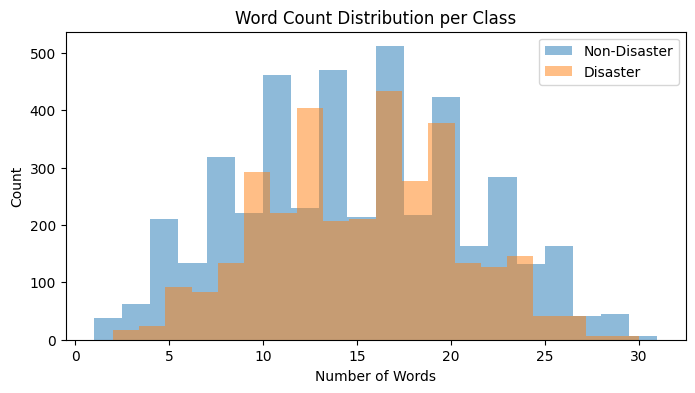

In [28]:
#Length
df['n_words'] = df['text'].str.split().str.len()

print(df.groupby('target')['n_words'].describe())

plt.figure(figsize=(8, 4))
plt.hist(df[df['target'] == 0]['n_words'], alpha=0.5, label='Non-Disaster', bins=20)
plt.hist(df[df['target'] == 1]['n_words'], alpha=0.5, label='Disaster', bins=20)
plt.legend()
plt.title('Word Count Distribution per Class')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

In [29]:
#Duplicate hunting
from sklearn.metrics.pairwise import cosine_similarity

subset_df = df.head(2500).copy()
vec = TfidfVectorizer()
tfidf_matrix = vec.fit_transform(subset_df['text'])

sim_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(sim_matrix, 0)

pairs = np.argwhere(sim_matrix > 0.75)
print(f"Found {len(pairs)} pairs with similarity > 0.75")

for idx1, idx2 in pairs[:5]:
    print(f"Tweet A (Target {subset_df.iloc[idx1]['target']}): {subset_df.iloc[idx1]['text']}")
    print(f"Tweet B (Target {subset_df.iloc[idx2]['target']}): {subset_df.iloc[idx2]['text']}")
    print("-" * 50)

Found 1242 pairs with similarity > 0.75
Tweet A (Target 0): Check these out: http://t.co/rOI2NSmEJJ http://t.co/3Tj8ZjiN21 http://t.co/YDUiXEfIpE http://t.co/LxTjc87KLS #nsfw
Tweet B (Target 0): Check these out: http://t.co/rOI2NSmEJJ http://t.co/3Tj8ZjiN21 http://t.co/YDUiXEfIpE http://t.co/LxTjc87KLS #nsfw
--------------------------------------------------
Tweet A (Target 0): Check these out: http://t.co/rOI2NSmEJJ http://t.co/3Tj8ZjiN21 http://t.co/YDUiXEfIpE http://t.co/LxTjc87KLS #nsfw
Tweet B (Target 0): Check these out: http://t.co/rOI2NSmEJJ http://t.co/3Tj8ZjiN21 http://t.co/YDUiXEfIpE http://t.co/LxTjc87KLS #nsfw
--------------------------------------------------
Tweet A (Target 1): I-77 Mile Marker 31 South Mooresville  Iredell Vehicle Accident Ramp Closed at 8/6 1:18 PM
Tweet B (Target 1): I-77 Mile Marker 31 to 40 South Mooresville  Iredell Vehicle Accident Congestion at 8/6 1:18 PM
--------------------------------------------------
Tweet A (Target 1): I-77 Mile Marker 31 

In [30]:
#Keywords
print(df['keyword'].value_counts().head(15))
print()
keyword_target = df.groupby('keyword')['target'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
print(keyword_target.head(10))

keyword
unknown        61
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
Name: count, dtype: int64

                   count      mean
keyword                           
debris                37  1.000000
derailment            39  1.000000
wreckage              39  1.000000
outbreak              40  0.975000
oil%20spill           38  0.973684
typhoon               38  0.973684
suicide%20bombing     33  0.969697
suicide%20bomber      31  0.967742
bombing               29  0.931034
suicide%20bomb        35  0.914286


In [31]:
#split train & test
X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train size: 6090 | Test size: 1523

Train class balance:
target
0    0.570279
1    0.429721
Name: proportion, dtype: float64

Test class balance:
target
0    0.570584
1    0.429416
Name: proportion, dtype: float64


In [32]:
baseline_pipe = Pipeline([
    ('vec', CountVectorizer()),
    ('clf', MultinomialNB())
])

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(baseline_pipe, X_train, y_train, cv=cv_strat, scoring='f1')

print(f"Baseline F1 Scores across 5 folds: {scores}")
print(f"Mean F1: {scores.mean():.4f}")
print(f"Std F1 : {scores.std():.4f}")

Baseline F1 Scores across 5 folds: [0.74824473 0.74623872 0.73435897 0.75770021 0.7523511 ]
Mean F1: 0.7478
Std F1 : 0.0078


In [33]:
#Model Exploration
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

vectorizers = {
    'CountVectorizer': CountVectorizer(),
    'TfidfVectorizer': TfidfVectorizer()
}

classifiers = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LinearSVC': LinearSVC(random_state=RANDOM_STATE)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for vec_name, vec in vectorizers.items():
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([
            ('vec', vec),
            ('clf', clf)
        ])

        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')

        results.append({
            'Vectorizer': vec_name,
            'Classifier': clf_name,
            'Mean F1': scores.mean(),
            'Std F1': scores.std()
        })

results_df = pd.DataFrame(results).sort_values(by='Mean F1', ascending=False)
print(results_df.to_string(index=False))

     Vectorizer         Classifier  Mean F1   Std F1
CountVectorizer      MultinomialNB 0.747779 0.007772
TfidfVectorizer LogisticRegression 0.744950 0.015235
TfidfVectorizer          LinearSVC 0.742852 0.014034
CountVectorizer LogisticRegression 0.741303 0.012884
CountVectorizer          LinearSVC 0.729751 0.003552
TfidfVectorizer      MultinomialNB 0.710411 0.014496


In [35]:
# Tuning TfidfVectorizer + LogisticRegression (High Baseline Performance)
pipeline = Pipeline([
    ('vec', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__min_df': [1, 2],
    'clf__C': [0.1, 1.0, 5.0, 10.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Best Hyperparameters: {'clf__C': 5.0, 'vec__min_df': 1, 'vec__ngram_range': (1, 1)}
Best Cross-Validation F1 Score: 0.7501


In [36]:
# Predict ONLY once on the hold-out test set
y_pred = best_model.predict(X_test)

print("="*50)
print("          FINAL TEST SET PERFORMANCE          ")
print("="*50)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Disaster', 'Disaster']))

          FINAL TEST SET PERFORMANCE          
Accuracy : 0.8070
Precision: 0.7866
Recall   : 0.7554
F1 Score : 0.7707

Classification Report:

              precision    recall  f1-score   support

Non-Disaster       0.82      0.85      0.83       869
    Disaster       0.79      0.76      0.77       654

    accuracy                           0.81      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523



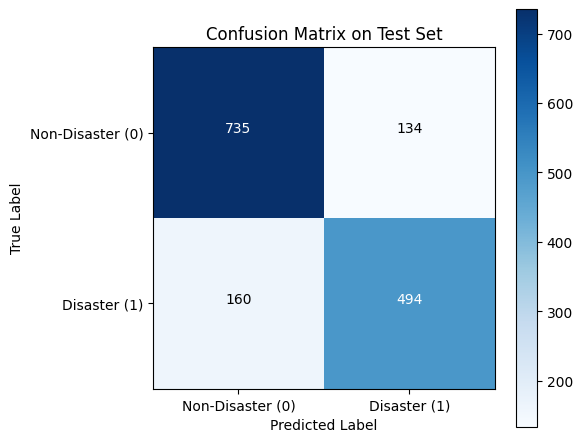


Total Errors: 294 out of 1523 test samples

--- Sample False Positives (Non-Disaster predicted as Disaster) ---
• @TheEconomist Step one: get that mass murderer's portrait off the yuan.
• @nagel_ashley @Vicken52 @BasedLaRock @goonc1ty rip the world... its burning
• if firefighters acted like cops they'd drive around shooting a flamethrower at burning buildings

--- Sample False Negatives (Disaster predicted as Non-Disaster) ---
• Hollywood Movie About Trapped Miners Released in Chile: 'The 33' Hollywood movie about trapped miners starring... http://t.co/tyyfG4qQvM
• I can't drown my demons they know how to swim
• @XHNews We need these plants in the pacific during the cyclone seasons it would help


In [37]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Non-Disaster (0)', 'Disaster (1)'])
plt.yticks(tick_marks, ['Non-Disaster (0)', 'Disaster (1)'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2.0 else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Error Analysis
test_df = pd.DataFrame({'text': X_test, 'actual': y_test, 'predicted': y_pred})
errors = test_df[test_df['actual'] != test_df['predicted']]

print(f"\nTotal Errors: {len(errors)} out of {len(X_test)} test samples")

print("\n--- Sample False Positives (Non-Disaster predicted as Disaster) ---")
for t in errors[(errors['actual'] == 0) & (errors['predicted'] == 1)]['text'].head(3):
    print(f"• {t}")

print("\n--- Sample False Negatives (Disaster predicted as Non-Disaster) ---")
for t in errors[(errors['actual'] == 1) & (errors['predicted'] == 0)]['text'].head(3):
    print(f"• {t}")

In [46]:
URL_AR = "https://raw.githubusercontent.com/mahmoudnabil/ASTD/master/data/Tweets.txt"
try:
    ar = pd.read_csv("astd_tweets.tsv", sep="\t", header=None, names=["text", "label"])
except FileNotFoundError:
    ar = pd.read_csv(URL_AR, sep="\t", header=None, names=["text", "label"])
ar["text"] = ar["text"].astype(str)

print(f"Loaded {len(ar)} Arabic tweets")
print(ar["label"].value_counts())
ar.head(3)

Loaded 9694 Arabic tweets
label
OBJ        6470
NEG        1642
NEUTRAL     805
POS         777
Name: count, dtype: int64


,text,label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG


In [47]:
#Arabic NLP & Dialect Handling
\from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re

# 1. Split Arabic dataset
X_ar = ar['text']
y_ar = ar['label']

X_train_ar, X_test_ar, y_train_ar, y_test_ar = train_test_split(
    X_ar, y_ar, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ar
)

# 2. Majority Class Baseline
maj_label = y_train_ar.value_counts().idxmax()
maj_preds = [maj_label] * len(y_test_ar)

acc_maj = accuracy_score(y_test_ar, maj_preds)
macro_f1_maj = f1_score(y_test_ar, maj_preds, average='macro')

print(f"Majority Class Baseline ('{maj_label}'):")
print(f"Accuracy : {acc_maj:.4f}")
print(f"Macro F1 : {macro_f1_maj:.4f}")

Majority Class Baseline ('OBJ'):
Accuracy : 0.6674
Macro F1 : 0.2001


In [48]:
#Word-level model
ar_word_pipe = Pipeline([
    ('vec', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

skf_ar = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ar_scores = cross_val_score(ar_word_pipe, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro')

print(f"Arabic Word-Level Baseline CV Macro F1: {ar_scores.mean():.4f} ± {ar_scores.std():.4f}")

Arabic Word-Level Baseline CV Macro F1: 0.2864 ± 0.0068


In [49]:
#Text Normalisation for Arabic
def normalize_ar(text):
    text = str(text)
    # Remove URLs and Mentions
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    # Remove Tashkeel (Diacritics) & Tatweel (Kashida)
    text = re.sub(r'[\u064B-\u0652]', '', text)
    text = re.sub(r'\u0640', '', text)
    # Standardize Letter Variants
    text = re.sub(r'[إأآ]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    # Remove Repeated Characters (Elongation: e.g. ههههههه -> هه)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    # Keep only Arabic characters
    text = re.sub(r'[^\u0621-\u064A\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Visual check on raw vs normalized text
for i in range(3):
    print(f"RAW  : {X_train_ar.iloc[i]}")
    print(f"NORM : {normalize_ar(X_train_ar.iloc[i])}\n")

# Evaluation with Normalization
ar_norm_pipe = Pipeline([
    ('vec', TfidfVectorizer(preprocessor=normalize_ar)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

norm_scores = cross_val_score(ar_norm_pipe, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro')
print(f"Arabic Normalised CV Macro F1: {norm_scores.mean():.4f} ± {norm_scores.std():.4f}")

RAW  : 2) وقوات مسلحة لا يتدخل بشئونها أحد ولمجلسها حق الفيتو على الدستور وغيره
NORM : وقوات مسلحه لا يتدخل بشئونها احد ولمجلسها حق الفيتو علي الدستور وغيره

RAW  : مدير جامعة الإمام يستنكر الثناء على #أردوغان ويعتبر #تركيا دولة فاسدة فاسقة فاجرة تنشر الرذيلة #عسير #السعودية # #
NORM : مدير جامعه الامام يستنكر الثناء علي اردوغان ويعتبر تركيا دوله فاسده فاسقه فاجره تنشر الرذيله عسير السعوديه

RAW  : الانسحاب من عضوية التأسيسية ومن لجنتها الاستشارية موقف وطني، التأسيسية فاقدة للشرعية الأخلاقية والقانونية والسياسية، ومسودتها للدستور كارثية
NORM : الانسحاب من عضويه التاسيسيه ومن لجنتها الاستشاريه موقف وطني التاسيسيه فاقده للشرعيه الاخلاقيه والقانونيه والسياسيه ومسودتها للدستور كارثيه

Arabic Normalised CV Macro F1: 0.3001 ± 0.0079


In [50]:
#Character n-grams
pipe_char_24 = Pipeline([
    ('vec', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2, preprocessor=normalize_ar)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe_char_35 = Pipeline([
    ('vec', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, preprocessor=normalize_ar)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

sc_24 = cross_val_score(pipe_char_24, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro')
sc_35 = cross_val_score(pipe_char_35, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro')

print(f"Char_wb (2,4) CV Macro F1: {sc_24.mean():.4f} ± {sc_24.std():.4f}")
print(f"Char_wb (3,5) CV Macro F1: {sc_35.mean():.4f} ± {sc_35.std():.4f}")

Char_wb (2,4) CV Macro F1: 0.3274 ± 0.0073
Char_wb (3,5) CV Macro F1: 0.3189 ± 0.0040


In [51]:
#Arabic Stopwords & Stemming
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

ar_stops = set(stopwords.words('arabic'))
stemmer_ar = ISRIStemmer()

def proc_ar_sw(t):
    return " ".join([w for w in normalize_ar(t).split() if w not in ar_stops])

def proc_ar_stem(t):
    return " ".join([stemmer_ar.stem(w) for w in normalize_ar(t).split() if w not in ar_stops])

ar_ablation = {
    "1. Normalised Only": X_train_ar.apply(normalize_ar),
    "2. Normalised + Stopwords": X_train_ar.apply(proc_ar_sw),
    "3. Normalised + ISRI Stemming": X_train_ar.apply(proc_ar_stem)
}

ar_results = []
for name, data in ar_ablation.items():
    p = Pipeline([('vec', TfidfVectorizer()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    sc = cross_val_score(p, data, y_train_ar, cv=skf_ar, scoring='f1_macro')
    p.fit(data, y_train_ar)
    vocab = len(p.named_steps['vec'].vocabulary_)
    ar_results.append({
        'Version': name,
        'Macro F1': round(sc.mean(), 4),
        'Std': round(sc.std(), 4),
        'Vocab Size': vocab
    })

# Add Char n-gram row for final comparison
pipe_char_24.fit(X_train_ar, y_train_ar)
c_vocab = len(pipe_char_24.named_steps['vec'].vocabulary_)
ar_results.append({
    'Version': "4. Char_wb (2,4) [Winner]",
    'Macro F1': round(sc_24.mean(), 4),
    'Std': round(sc_24.std(), 4),
    'Vocab Size': c_vocab
})

print(pd.DataFrame(ar_results).to_string(index=False))

                      Version  Macro F1    Std  Vocab Size
           1. Normalised Only    0.3001 0.0079       28073
    2. Normalised + Stopwords    0.2955 0.0118       27842
3. Normalised + ISRI Stemming    0.3389 0.0105        7704
    4. Char_wb (2,4) [Winner]    0.3274 0.0073       31725


In [ ]:
#Imbalance — the decisive experiment
ar_unbal = Pipeline([
    ('vec', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2, preprocessor=normalize_ar)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

ar_bal = Pipeline([
    ('vec', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2, preprocessor=normalize_ar)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

f1_u = cross_val_score(ar_unbal, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro').mean()
acc_u = cross_val_score(ar_unbal, X_train_ar, y_train_ar, cv=skf_ar, scoring='accuracy').mean()

f1_b = cross_val_score(ar_bal, X_train_ar, y_train_ar, cv=skf_ar, scoring='f1_macro').mean()
acc_b = cross_val_score(ar_bal, X_train_ar, y_train_ar, cv=skf_ar, scoring='accuracy').mean()

print(f"Unbalanced Model -> Accuracy: {acc_u:.4f} | Macro F1: {f1_u:.4f}")
print(f"Balanced Model   -> Accuracy: {acc_b:.4f} | Macro F1: {f1_b:.4f}")

In [ ]:
#Final Arabic Evaluation & Diagnostic Confusion Matrix
# Train best Arabic pipeline on full training data and test on unseen test set
ar_bal.fit(X_train_ar, y_train_ar)
y_pred_ar = ar_bal.predict(X_test_ar)

print("=== Final Arabic Model Performance (Test Set) ===")
print(classification_report(y_test_ar, y_pred_ar, digits=4))

print("\n=== Confusion Matrix ===")
cm_ar = confusion_matrix(y_test_ar, y_pred_ar, labels=ar_bal.classes_)
cm_df = pd.DataFrame(cm_ar, index=ar_bal.classes_, columns=ar_bal.classes_)
print(cm_df)